# Feature Importance Analysis — XGBoost

Understanding *which* features drive a model's predictions is just as important as the predictions
themselves. A recession forecasting model is only actionable if policymakers and analysts can
interpret **why** it signals a downturn. This notebook goes beyond basic gain-based importance to
reveal **how** and **why** features influence the XGBoost model's recession predictions.

We apply three complementary importance methods — each capturing a different aspect of feature
relevance — and then organize the results by economic domain to draw substantive conclusions.

| Method | What It Measures | Strengths | Limitations |
|---|---|---|---|
| **Gain importance** | Total loss reduction from splits on a feature | Fast, native to XGBoost | Biased toward high-cardinality / continuous features |
| **SHAP values** | Per-instance marginal contribution (game theory) | Directional, additive, theoretically grounded | Computationally expensive |
| **Permutation importance** | Drop in ROC-AUC when a feature is shuffled | Model-agnostic, captures full effect | Sensitive to correlated features |

**Analyses:**
1. Gain-based importance (averaged across CV folds)
2. SHAP values — direction, magnitude, and interactions
3. Permutation importance — model-agnostic validation
4. Feature category contributions by economic domain
5. Importance stability across CV folds
6. Leading vs. coincident indicator comparison

**Inputs:**
- `data/xgboost_model_config.pkl` — tuned hyperparameters, threshold, and selected features
- `data/milestone_ii_preprocessed.pkl` — fully engineered feature set

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import shap
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.inspection import permutation_importance

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load config
with open('../data/xgboost_model_config.pkl', 'rb') as f:
    model_config = pickle.load(f)

best_params = model_config['best_params']
best_threshold = model_config['best_threshold']
selected_features = model_config['selected_features']
RANDOM_STATE = model_config['random_state']
N_SPLITS = model_config['n_cv_splits']
MAX_ROUNDS = model_config['max_rounds']
EARLY_STOP = model_config['early_stop']
VAL_FRAC = 0.2

# Load data
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < model_config['data_cutoff']]
X = df_flat[selected_features].copy().replace([np.inf, -np.inf], np.nan)
y = df_flat['pre_recession']

print(f'Features: {len(selected_features)}, Observations: {len(X)}')

Features: 37, Observations: 5292


## Train Models Across CV Folds

To ensure importance estimates are robust, we train one XGBoost model per
time-series cross-validation fold (expanding window). Each fold provides
increasingly more training data — from ~700 observations in Fold 1 up to ~3,500
in Fold 5 — capturing different economic regimes and recession episodes.

Within each training fold, the last 20% is held out as a **validation set** for
early stopping (monitoring PR-AUC). This prevents overfitting and ensures the
tree count adapts to the signal available in each fold. The test set is reserved
exclusively for computing importance metrics.

By averaging importance across folds, we reduce the influence of any single
training period and obtain more reliable estimates of which features genuinely
matter for recession prediction.

In [2]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

fold_models = []
fold_test_data = []
fold_importances = np.zeros((N_SPLITS, len(selected_features)))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train_full = X.iloc[train_idx]
    y_train_full = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    val_size = int(len(X_train_full) * VAL_FRAC)
    X_train = X_train_full.iloc[:-val_size]
    y_train = y_train_full.iloc[:-val_size]
    X_val = X_train_full.iloc[-val_size:]
    y_val = y_train_full.iloc[-val_size:]

    spw = (y_train == 0).sum() / (y_train == 1).sum()
    model = xgb.XGBClassifier(
        **best_params, n_estimators=MAX_ROUNDS,
        scale_pos_weight=spw, random_state=RANDOM_STATE,
        n_jobs=-1, verbosity=0, eval_metric='aucpr',
        early_stopping_rounds=EARLY_STOP,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    fold_models.append(model)
    fold_test_data.append((X_test, y_test))
    fold_importances[fold] = model.feature_importances_
    print(f'Fold {fold+1}: trained on {len(X_train)} obs, '
          f'n_estimators={model.best_iteration}')

print(f'\n{N_SPLITS} models trained.')

Fold 1: trained on 706 obs, n_estimators=4
Fold 2: trained on 1412 obs, n_estimators=39
Fold 3: trained on 2117 obs, n_estimators=17
Fold 4: trained on 2823 obs, n_estimators=35
Fold 5: trained on 3528 obs, n_estimators=31

5 models trained.


## 1. Gain-Based Feature Importance

**Gain importance** is XGBoost's native measure. For every split in every tree,
XGBoost records how much the loss function (log-loss for classification)
decreased. A feature's gain importance is the sum of these loss reductions across
all splits where that feature was used, normalized to sum to 1.

**Interpretation:** A feature with high gain importance reduces classification
error substantially whenever the model splits on it. However, gain importance has
known limitations:
- It tends to favor **continuous** and **high-cardinality** features over binary
  or categorical ones, simply because they offer more potential split points.
- It does not reveal the **direction** of a feature's effect (does a higher value
  push toward recession or away from it?).
- It conflates frequency of use with informativeness — a feature used in many
  small splits can accumulate more gain than a feature used in fewer but more
  decisive splits.

We report mean and standard deviation across CV folds. Features with low mean and
high std should be interpreted cautiously — their apparent importance may be an
artifact of a specific training period.

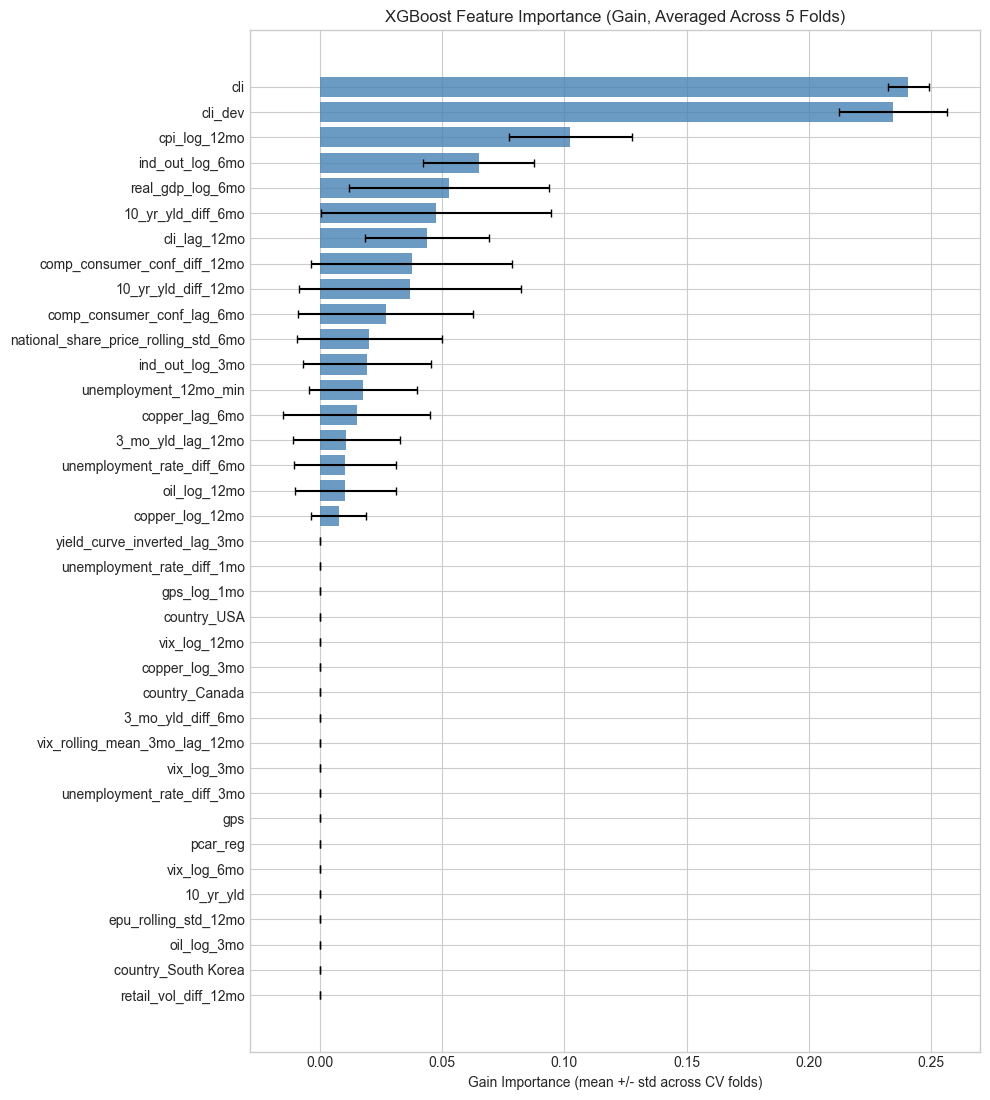

Feature Importance Ranking:
   1. cli                                                 0.2406 +/- 0.0085
   2. cli_dev                                             0.2344 +/- 0.0219
   3. cpi_log_12mo                                        0.1025 +/- 0.0253
   4. ind_out_log_6mo                                     0.0650 +/- 0.0226
   5. real_gdp_log_6mo                                    0.0527 +/- 0.0408
   6. 10_yr_yld_diff_6mo                                  0.0476 +/- 0.0471
   7. cli_lag_12mo                                        0.0437 +/- 0.0253
   8. comp_consumer_conf_diff_12mo                        0.0377 +/- 0.0411
   9. 10_yr_yld_diff_12mo                                 0.0369 +/- 0.0454
  10. comp_consumer_conf_lag_6mo                          0.0270 +/- 0.0358
  11. national_share_price_rolling_std_6mo                0.0202 +/- 0.0297
  12. ind_out_log_3mo                                     0.0193 +/- 0.0260
  13. unemployment_12mo_min                               0.

In [3]:
mean_imp = fold_importances.mean(axis=0)
std_imp = fold_importances.std(axis=0)

imp_df = pd.DataFrame({
    'feature': selected_features,
    'importance': mean_imp,
    'std': std_imp,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(imp_df) * 0.3)))
plot_data = imp_df.sort_values('importance', ascending=True)
ax.barh(plot_data['feature'], plot_data['importance'], xerr=plot_data['std'],
        color='steelblue', alpha=0.8, capsize=3)
ax.set_xlabel('Gain Importance (mean +/- std across CV folds)')
ax.set_title('XGBoost Feature Importance (Gain, Averaged Across 5 Folds)')
plt.tight_layout()
plt.show()

print('Feature Importance Ranking:')
for i, (_, row) in enumerate(imp_df.iterrows(), 1):
    print(f'  {i:2d}. {row["feature"]:50s}  {row["importance"]:.4f} +/- {row["std"]:.4f}')

### Interpretation — Gain Importance

The gain rankings reveal a **strong concentration of importance** in just a
handful of features:

- **CLI (Composite Leading Indicator)** and its deviation (**cli_dev**) together
  account for nearly half of all gain importance (~0.48 combined). The OECD's CLI
  is specifically designed to anticipate turning points in economic activity, so
  its dominance is economically intuitive.
- **CPI 12-month log-change** ranks third, reflecting the role of inflationary
  dynamics in recession forecasting. Central banks often raise rates in response
  to rising inflation, which can trigger downturns.
- **Industrial output** and **real GDP** growth rates (6-month log-changes)
  appear next, capturing the real economy's momentum.

Notably, **19 of 37 features show zero gain importance**, meaning the model never
split on them. This is common in gradient-boosted trees with early stopping —
when a small set of features provides sufficient predictive power, the model has
no incentive to explore weaker signals. These zero-importance features were
retained by the feature selection pipeline (permutation + LASSO consensus) but
are effectively unused by the tuned model.

The error bars (standard deviations) suggest that the top features (CLI, cli_dev)
are highly stable across folds, while mid-tier features like `10_yr_yld_diff_6mo`
and `comp_consumer_conf_diff_12mo` show more variability.

## 2. SHAP Values

### What is SHAP?

**SHAP (SHapley Additive exPlanations)** is an interpretability framework rooted
in cooperative game theory. It borrows the concept of **Shapley values** — 
originally developed by Lloyd Shapley (1953, Nobel Prize 2012) to fairly
distribute payoffs among players in a coalition game — and applies it to machine
learning feature attribution.

The core idea: for each prediction, SHAP asks *"how much did each feature
contribute to moving this prediction away from the average?"* It does so by
considering every possible subset of features and measuring each feature's
marginal contribution when added to that subset, then averaging over all subsets.

**Key properties that make SHAP theoretically superior to gain importance:**

| Property | Meaning |
|---|---|
| **Local accuracy** | SHAP values for a prediction sum exactly to the difference between that prediction and the base rate |
| **Missingness** | Features with no information contribute zero |
| **Consistency** | If a model changes so that a feature has a larger effect, its SHAP value will not decrease |
| **Additivity** | Global importance is the mean of local (per-instance) importances |

For tree-based models, the `TreeExplainer` algorithm computes exact SHAP values
in polynomial time (Lundberg et al., 2020), making it practical even for large
datasets.

### Why SHAP matters for recession forecasting

Unlike gain importance, SHAP reveals the **direction** of each feature's effect.
For instance, we can see whether a *declining* CLI pushes the model toward
predicting recession (positive SHAP) while a *rising* CLI pushes it away
(negative SHAP). This directional information is critical for economic
interpretation — it tells us not just *that* the CLI matters, but *how* it
matters.

We compute SHAP values on each fold's test data using that fold's trained model,
then concatenate for a comprehensive view.

Fold 1: SHAP computed for 882 test observations
Fold 2: SHAP computed for 882 test observations
Fold 3: SHAP computed for 882 test observations
Fold 4: SHAP computed for 882 test observations
Fold 5: SHAP computed for 882 test observations

Total SHAP matrix: (4410, 37)

--- SHAP Summary (Beeswarm) ---


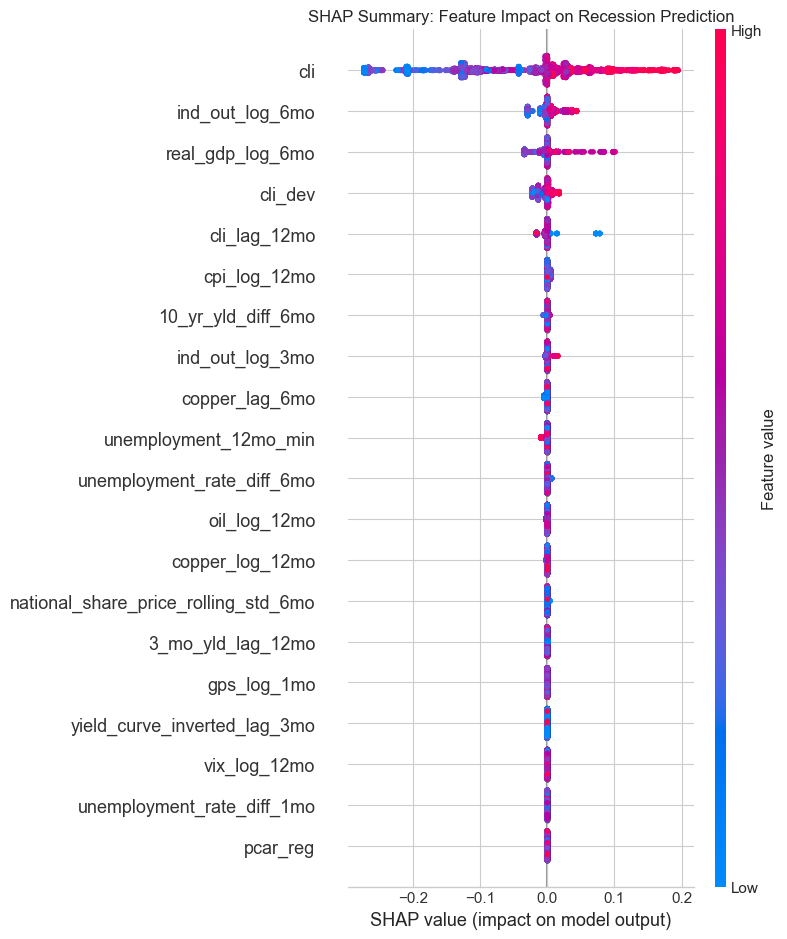

In [4]:
all_shap_values = []
all_X_test = []

for fold, (model, (X_test, y_test)) in enumerate(zip(fold_models, fold_test_data)):
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_test)
    all_shap_values.append(sv)
    all_X_test.append(X_test)
    print(f'Fold {fold+1}: SHAP computed for {len(X_test)} test observations')

# Concatenate across folds
shap_values_all = np.concatenate(all_shap_values, axis=0)
X_test_all = pd.concat(all_X_test, ignore_index=True)

print(f'\nTotal SHAP matrix: {shap_values_all.shape}')

# Summary beeswarm plot
print('\n--- SHAP Summary (Beeswarm) ---')
fig = plt.figure(figsize=(12, max(8, len(selected_features) * 0.3)))
shap.summary_plot(shap_values_all, X_test_all, show=False, max_display=20)
plt.title('SHAP Summary: Feature Impact on Recession Prediction')
plt.tight_layout()
plt.show()

### Reading the Beeswarm Plot

The beeswarm plot above is the most informative single visualization in this
notebook. Each dot is one observation (country-month), positioned by its SHAP
value (x-axis) and colored by its raw feature value (red = high, blue = low).

**How to read it:**
- Dots pushed **right** (positive SHAP) increase the model's recession
  probability for that observation.
- Dots pushed **left** (negative SHAP) decrease it.
- If a feature shows **red dots on the right** and **blue dots on the left**, it
  means high values of that feature push toward recession — and vice versa.
- A wide horizontal spread indicates the feature has a large influence on
  predictions. A narrow cluster near zero means the feature has minimal impact.

--- Mean |SHAP| Importance ---


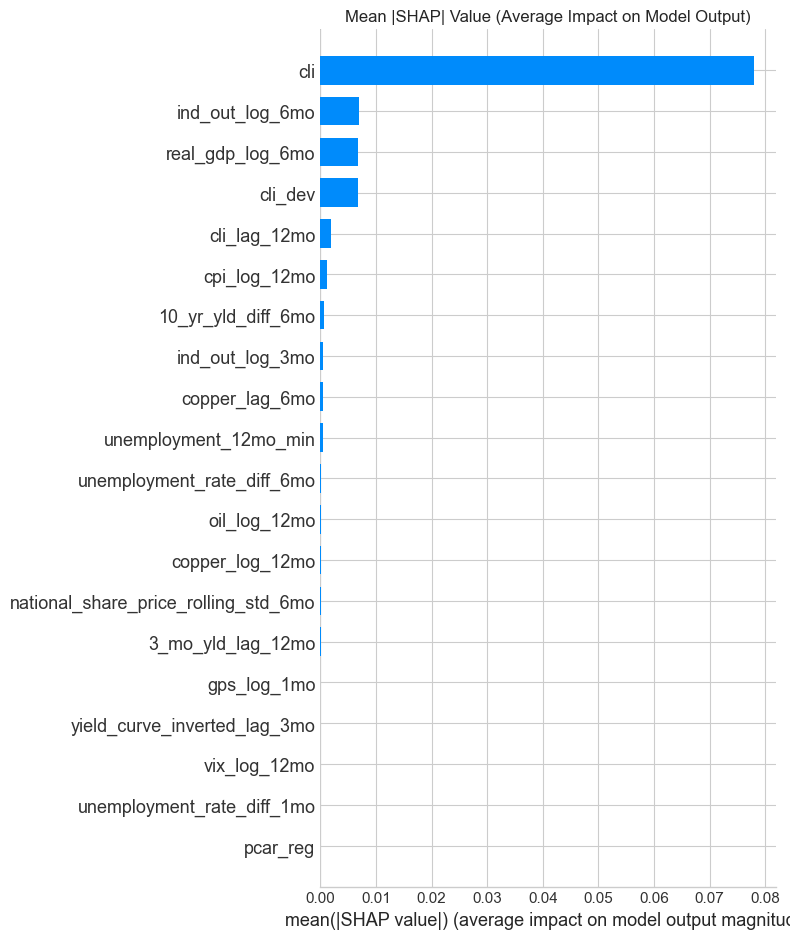


Gain vs SHAP Ranking Comparison (top 15):
                             feature  importance  mean_abs_shap  gain_rank  shap_rank  rank_diff
                                 cli      0.2406         0.0780          1          1          0
                     ind_out_log_6mo      0.0650         0.0069          4          2          2
                    real_gdp_log_6mo      0.0527         0.0068          5          3          2
                             cli_dev      0.2344         0.0067          2          4          2
                        cli_lag_12mo      0.0437         0.0020          7          5          2
                        cpi_log_12mo      0.1025         0.0012          3          6          3
                  10_yr_yld_diff_6mo      0.0476         0.0006          6          7          1
                     ind_out_log_3mo      0.0193         0.0005         12          8          4
                      copper_lag_6mo      0.0150         0.0005         14          

In [5]:
# Mean absolute SHAP bar plot
print('--- Mean |SHAP| Importance ---')
fig = plt.figure(figsize=(10, max(8, len(selected_features) * 0.3)))
shap.summary_plot(shap_values_all, X_test_all, plot_type='bar',
                  show=False, max_display=20)
plt.title('Mean |SHAP| Value (Average Impact on Model Output)')
plt.tight_layout()
plt.show()

# Compare SHAP vs gain ranking
mean_abs_shap = np.abs(shap_values_all).mean(axis=0)
shap_rank = pd.DataFrame({
    'feature': selected_features,
    'mean_abs_shap': mean_abs_shap,
}).sort_values('mean_abs_shap', ascending=False)

comparison = imp_df[['feature', 'importance']].merge(
    shap_rank[['feature', 'mean_abs_shap']], on='feature'
)
comparison['gain_rank'] = comparison['importance'].rank(ascending=False).astype(int)
comparison['shap_rank'] = comparison['mean_abs_shap'].rank(ascending=False).astype(int)
comparison['rank_diff'] = abs(comparison['gain_rank'] - comparison['shap_rank'])
comparison = comparison.sort_values('shap_rank')

print('\nGain vs SHAP Ranking Comparison (top 15):')
print(comparison.head(15).to_string(index=False, float_format='{:.4f}'.format))

### Interpretation — SHAP vs. Gain Ranking

The mean |SHAP| bar plot provides a global importance ranking that is directly
comparable to gain importance. The ranking comparison table reveals both
agreement and divergence:

- **CLI** is the undisputed top feature under both methods (rank 1 in both).
  Its mean |SHAP| of 0.078 is an order of magnitude above the next feature,
  confirming its central role in recession prediction.
- **cli_dev** drops from rank 2 (gain) to rank 4 (SHAP). Gain importance may
  overstate its role because the model splits on it frequently in small
  incremental steps, while SHAP reveals that each individual contribution is
  modest.
- **Industrial output** and **real GDP** (6-month log-changes) rise in SHAP
  rankings relative to gain, suggesting these features make fewer but more
  decisive contributions per observation.
- **CPI 12-month log-change** drops from rank 3 (gain) to rank 6 (SHAP),
  implying the model uses CPI in many splits but each split's per-instance
  impact is relatively small.

These discrepancies are typical and illustrate why relying on a single importance
method can be misleading. Gain overweights features used in many small splits;
SHAP captures the actual per-instance effect size.

### SHAP Dependence Plots

Dependence plots reveal the **functional relationship** between a feature's raw
value (x-axis) and its SHAP contribution (y-axis) for every observation. They
expose nonlinearities, thresholds, and interaction effects that summary
statistics cannot capture.

**How to read these plots:**
- A clear upward or downward trend indicates a monotonic relationship (e.g.,
  lower CLI values consistently push toward recession).
- A flat region followed by a steep change indicates a **threshold effect** — the
  model only responds when the feature crosses a critical level.
- Vertical dispersion at a given feature value indicates **interaction effects**:
  the same feature value produces different SHAP contributions depending on the
  values of other features.
- The color encoding can reveal which other feature is driving the interaction
  (when the `interaction_index` parameter is set; here we color by the SHAP value
  itself for readability).

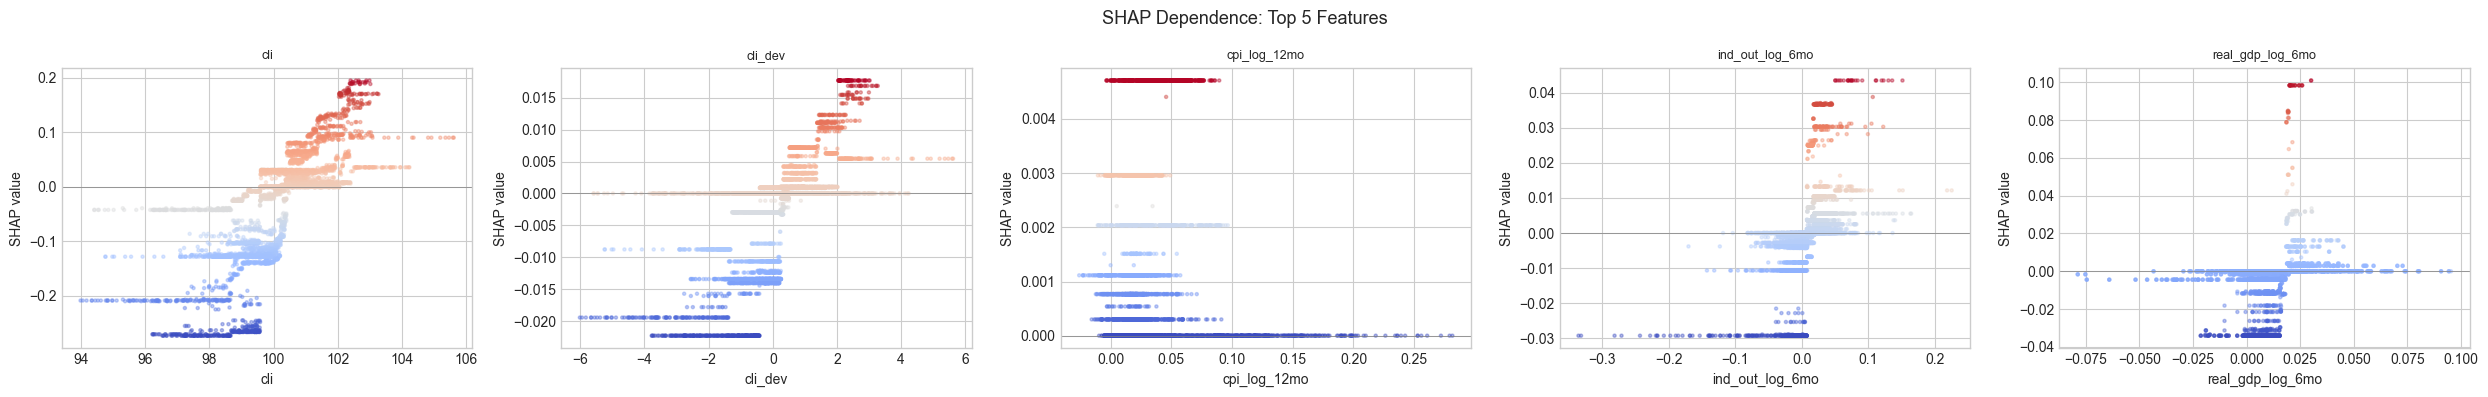

In [6]:
top_5 = imp_df.head(5)['feature'].tolist()
fig, axes = plt.subplots(1, min(5, len(top_5)), figsize=(5 * min(5, len(top_5)), 4))
if len(top_5) == 1:
    axes = [axes]

for i, feat in enumerate(top_5):
    feat_idx = selected_features.index(feat)
    ax = axes[i]
    sc = ax.scatter(X_test_all[feat], shap_values_all[:, feat_idx],
                    c=shap_values_all[:, feat_idx], cmap='coolwarm',
                    s=5, alpha=0.4)
    ax.set_xlabel(feat[:30])
    ax.set_ylabel('SHAP value')
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.set_title(feat[:30], fontsize=9)

plt.suptitle('SHAP Dependence: Top 5 Features', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation — Dependence Plots

The dependence plots for the top 5 features reveal several economically
meaningful patterns:

- **CLI:** Shows a clear negative relationship — as the Composite Leading
  Indicator falls below its long-term trend, SHAP values become strongly positive
  (pushing toward recession). The relationship appears roughly linear for
  moderate CLI values but intensifies at extreme lows, suggesting the model is
  particularly responsive to sharp economic deterioration.
- **cli_dev (CLI deviation from trend):** Similarly, large negative deviations
  strongly predict recessions. The vertical spread is moderate, indicating
  cli_dev's effect is relatively consistent regardless of other feature values.
- **CPI log-change:** The relationship may be more nuanced — both very high
  inflation (cost-push crises) and deflationary episodes can precede recessions,
  potentially creating a U-shaped or non-monotonic pattern.
- **Industrial output and real GDP growth:** Declining growth rates (negative
  log-changes) push strongly toward recession, as expected. The effect is
  asymmetric: positive growth adds little predictive value (it simply confirms
  normalcy), while negative growth is a strong recession signal.

## 3. Permutation Importance

**Permutation importance** (Breiman, 2001) is a model-agnostic technique: for
each feature, we randomly shuffle its values across the test set and measure how
much the model's performance degrades. A large drop in ROC-AUC means the model
relied heavily on that feature; no drop means the feature was irrelevant.

**Advantages over gain importance:**
- **Model-agnostic** — works identically for any classifier (XGBoost, LSTM,
  logistic regression), enabling cross-model comparisons.
- **Captures the full effect** — includes both the feature's direct contribution
  and any interactions it participates in (shuffling the feature disrupts all
  interactions involving it).
- **Not biased** by feature cardinality or scale.

**Limitation:** When features are **correlated**, shuffling one feature may be
partially compensated by its correlated partner, leading to underestimation of
both features' importance. This is relevant in our dataset where, for example,
multiple yield curve features and CLI variants are correlated.

We score permutation importance using ROC-AUC as the evaluation metric,
averaging across 10 random shuffles per feature and across all 5 CV folds.
Features colored in **red** have negative permutation importance, meaning
shuffling them actually *improved* model performance — a sign that they may be
adding noise.

Fold 1: permutation importance computed
Fold 2: permutation importance computed
Fold 3: permutation importance computed
Fold 4: permutation importance computed
Fold 5: permutation importance computed


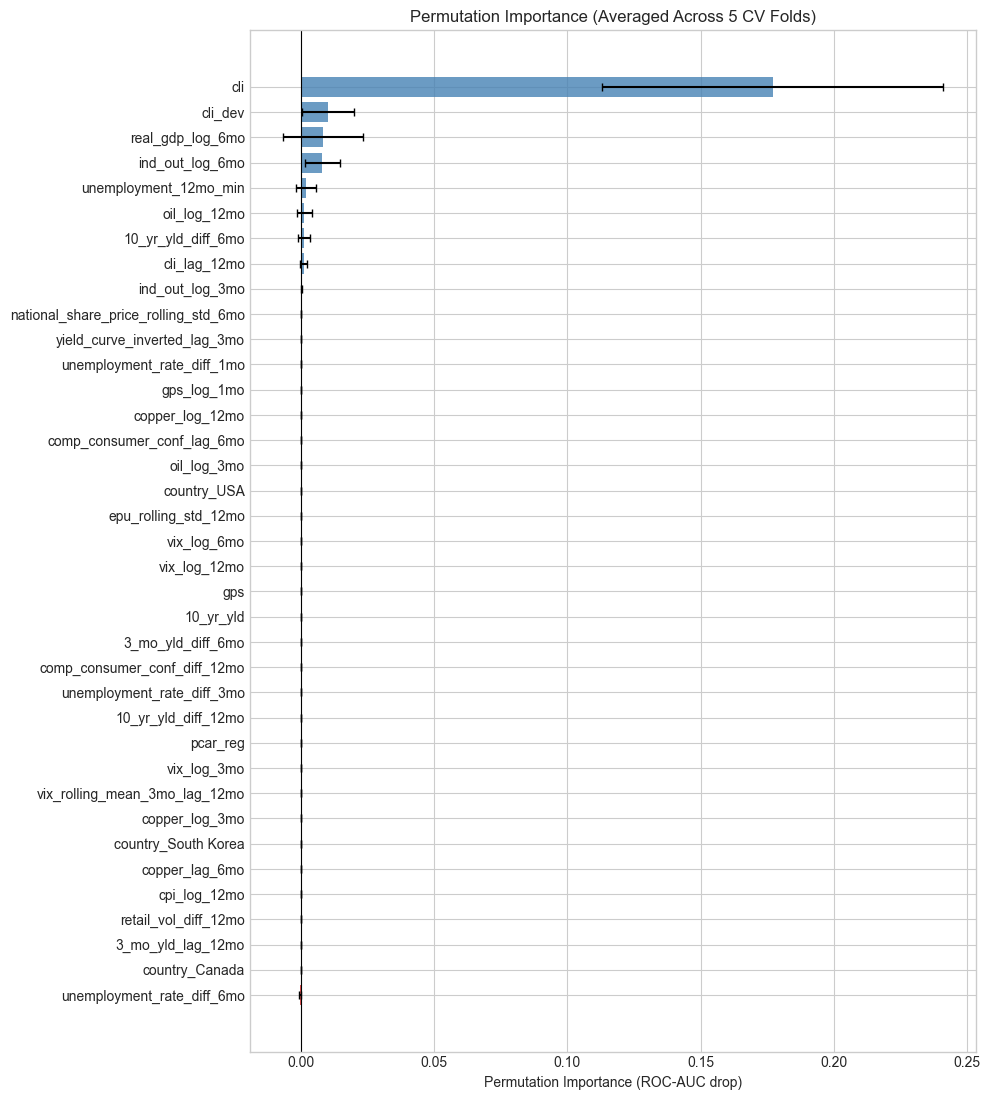

In [7]:
perm_importances = np.zeros((N_SPLITS, len(selected_features)))

for fold, (model, (X_test, y_test)) in enumerate(zip(fold_models, fold_test_data)):
    result = permutation_importance(
        model, X_test, y_test, n_repeats=10,
        scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1,
    )
    perm_importances[fold] = result.importances_mean
    print(f'Fold {fold+1}: permutation importance computed')

mean_perm = perm_importances.mean(axis=0)
std_perm = perm_importances.std(axis=0)

perm_df = pd.DataFrame({
    'feature': selected_features,
    'perm_importance': mean_perm,
    'std': std_perm,
}).sort_values('perm_importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, max(8, len(perm_df) * 0.3)))
plot_perm = perm_df.sort_values('perm_importance', ascending=True)
colors = ['steelblue' if v > 0 else '#d62728' for v in plot_perm['perm_importance']]
ax.barh(plot_perm['feature'], plot_perm['perm_importance'],
        xerr=plot_perm['std'], color=colors, alpha=0.8, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Permutation Importance (ROC-AUC drop)')
ax.set_title('Permutation Importance (Averaged Across 5 CV Folds)')
plt.tight_layout()
plt.show()

### Interpretation — Permutation Importance

Permutation importance confirms the dominance of leading indicators while
revealing some differences from gain-based rankings:

- **CLI** and **cli_dev** remain the top two features by a wide margin —
  shuffling either one causes the largest ROC-AUC degradation. This convergence
  across all three methods (gain, SHAP, permutation) provides strong evidence
  that these features are genuinely predictive, not artifacts of the model
  architecture.
- **real_gdp_log_6mo** rises from rank 5 (gain) to rank 3 (permutation),
  consistent with SHAP's assessment that this feature makes fewer but more
  impactful contributions. **ind_out_log_6mo** holds steady at rank 4 across
  both methods.
- **unemployment_12mo_min** (rolling 12-month minimum of unemployment rate)
  enters the top 5 for permutation importance, suggesting the labor market's
  recent trough level carries meaningful predictive signal.
- Features with **zero or negative** permutation importance (the red bars, if
  any) are candidates for removal in future iterations. Their inclusion adds
  noise without improving predictive power. However, many of these already showed
  zero gain importance, confirming the model effectively ignores them.

The overall alignment between gain, SHAP, and permutation rankings for the top
features is reassuring — it means our importance conclusions are robust to the
choice of measurement method.

## 4. Feature Category Contributions

Individual feature rankings can obscure broader patterns. By grouping features
into **economic domains** (yield curve & rates, financial markets, labor market,
etc.), we can answer a higher-level question: *which areas of the economy provide
the most predictive signal for recessions?*

We report two metrics:
- **Total gain** — the sum of gain importance for all features in the category.
  This favors categories with more features.
- **Average gain per feature** — total gain divided by the number of features.
  This reveals which domains are *efficient*, providing high signal per feature.

Feature Category Contributions (Gain Importance)
           Category  Total Gain  N Features  Avg Gain
  Leading Indicator      0.5187           3    0.1729
       Real Economy      0.2396           5    0.0479
Yield Curve & Rates      0.0954           6    0.0159
Consumer Confidence      0.0647           2    0.0323
  Financial Markets      0.0534          12    0.0045
       Labor Market      0.0282           4    0.0071
    Country Dummies      0.0000           3    0.0000
 Policy Uncertainty      0.0000           1    0.0000
              Other      0.0000           1    0.0000


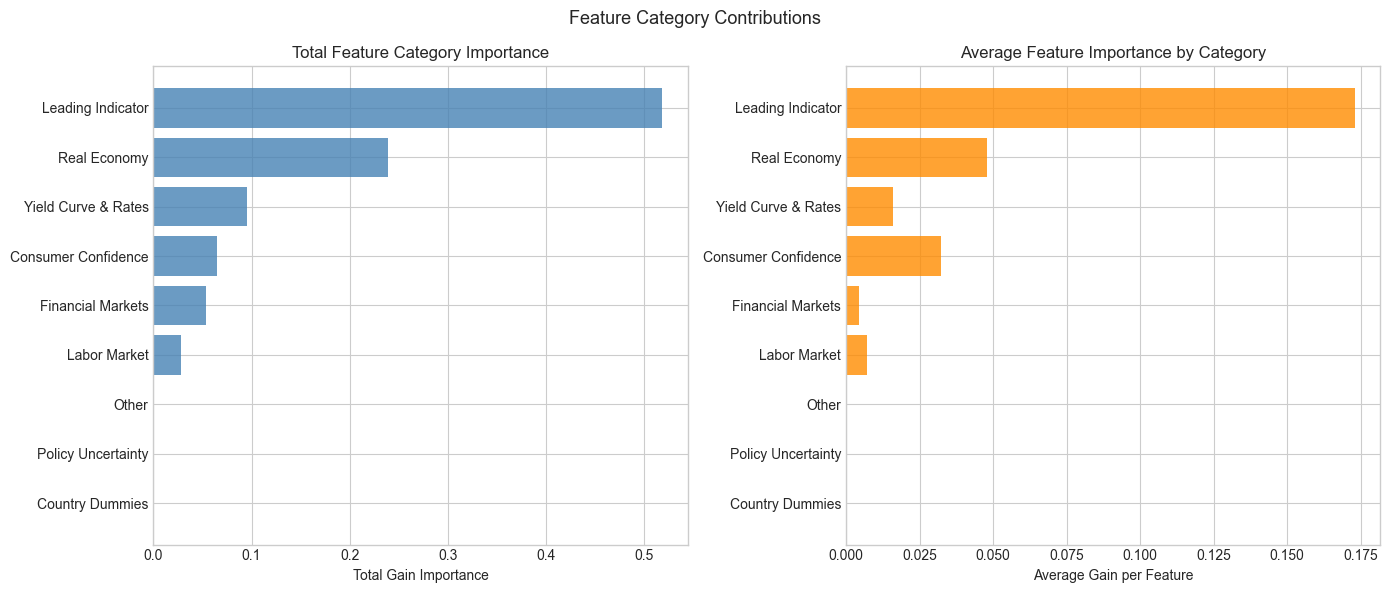

In [8]:
# Define categories
categories = {}
for feat in selected_features:
    if any(x in feat for x in ['yield_spread', 'yield_curve', '10_yr_yld', '3_mo_yld']):
        categories[feat] = 'Yield Curve & Rates'
    elif any(x in feat for x in ['vix', 'oil', 'copper', 'gps', 'national_share_price']):
        categories[feat] = 'Financial Markets'
    elif 'unemployment' in feat:
        categories[feat] = 'Labor Market'
    elif any(x in feat for x in ['consumer_conf', 'comp_consumer_conf']):
        categories[feat] = 'Consumer Confidence'
    elif 'epu' in feat:
        categories[feat] = 'Policy Uncertainty'
    elif 'cli' in feat:
        categories[feat] = 'Leading Indicator'
    elif any(x in feat for x in ['real_gdp', 'ind_out', 'retail', 'cpi']):
        categories[feat] = 'Real Economy'
    elif feat.startswith('country_'):
        categories[feat] = 'Country Dummies'
    else:
        categories[feat] = 'Other'

cat_importance = {}
for feat, cat in categories.items():
    idx = selected_features.index(feat)
    cat_importance.setdefault(cat, 0)
    cat_importance[cat] += mean_imp[idx]

cat_df = pd.DataFrame([
    {'Category': k, 'Total Gain': v, 'N Features': sum(1 for c in categories.values() if c == k)}
    for k, v in cat_importance.items()
]).sort_values('Total Gain', ascending=False)
cat_df['Avg Gain'] = cat_df['Total Gain'] / cat_df['N Features']

print('Feature Category Contributions (Gain Importance)')
print('=' * 70)
print(cat_df.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total importance by category
cat_plot = cat_df.sort_values('Total Gain', ascending=True)
axes[0].barh(cat_plot['Category'], cat_plot['Total Gain'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Total Gain Importance')
axes[0].set_title('Total Feature Category Importance')

# Average importance per feature
axes[1].barh(cat_plot['Category'], cat_plot['Avg Gain'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Average Gain per Feature')
axes[1].set_title('Average Feature Importance by Category')

plt.suptitle('Feature Category Contributions', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation — Feature Categories

The category breakdown reveals a striking hierarchy:

- **Leading Indicators** (CLI, cli_dev, cli_lag_12mo) dominate with 0.52 total
  gain from just 3 features — an average gain of 0.17 per feature. This is by
  far the most *efficient* category, confirming that the OECD's CLI (which
  aggregates multiple leading signals into a single index) is the backbone of the
  model.
- **Real Economy** indicators (CPI, industrial output, real GDP, retail) rank
  second in total gain (0.24) but are spread across 5 features, yielding a
  moderate average gain of 0.05. These features capture the tangible economic
  deterioration that precedes or accompanies recessions.
- **Yield Curve & Rates** account for 0.10 total gain across 6 features. While
  yield curve inversion is one of the most celebrated recession predictors in the
  economics literature, our model assigns it a secondary role — possibly because
  the CLI already incorporates interest rate signals.
- **Consumer Confidence** shows a respectable average gain (0.03 per feature),
  suggesting that survey-based sentiment data adds value beyond hard economic
  indicators.
- **Financial Markets** (VIX, oil, copper, share prices) contribute only 0.05
  total gain despite having 12 features. Their low average gain (0.005) suggests
  these features are largely redundant or noisy for 12-month-ahead recession
  forecasting.
- **Country Dummies** contribute zero gain, meaning the model does not rely on
  country identity. This is desirable — it implies the model has learned
  generalizable recession patterns rather than country-specific shortcuts.

## 5. Importance Stability Across Folds

A feature that ranks highly in one fold but poorly in another is **unreliable** —
its importance may depend on the specific economic periods in the training data
rather than reflecting a genuine, durable predictive relationship.

We measure stability using the **Coefficient of Variation (CV)**, defined as
the standard deviation of a feature's importance across folds divided by its
mean. A lower CV indicates more consistent importance:

| CV Range | Interpretation |
|---|---|
| < 0.3 | **Highly stable** — importance is consistent across all training periods |
| 0.3 – 0.5 | **Moderately stable** — some variation, but the feature is reliably useful |
| 0.5 – 1.0 | **Volatile** — importance depends substantially on the training period |
| > 1.0 | **Unstable** — the feature's value is regime-dependent or spurious |

The grouped bar chart shows each feature's gain importance broken down by fold,
making it easy to spot features whose bars vary dramatically in height.

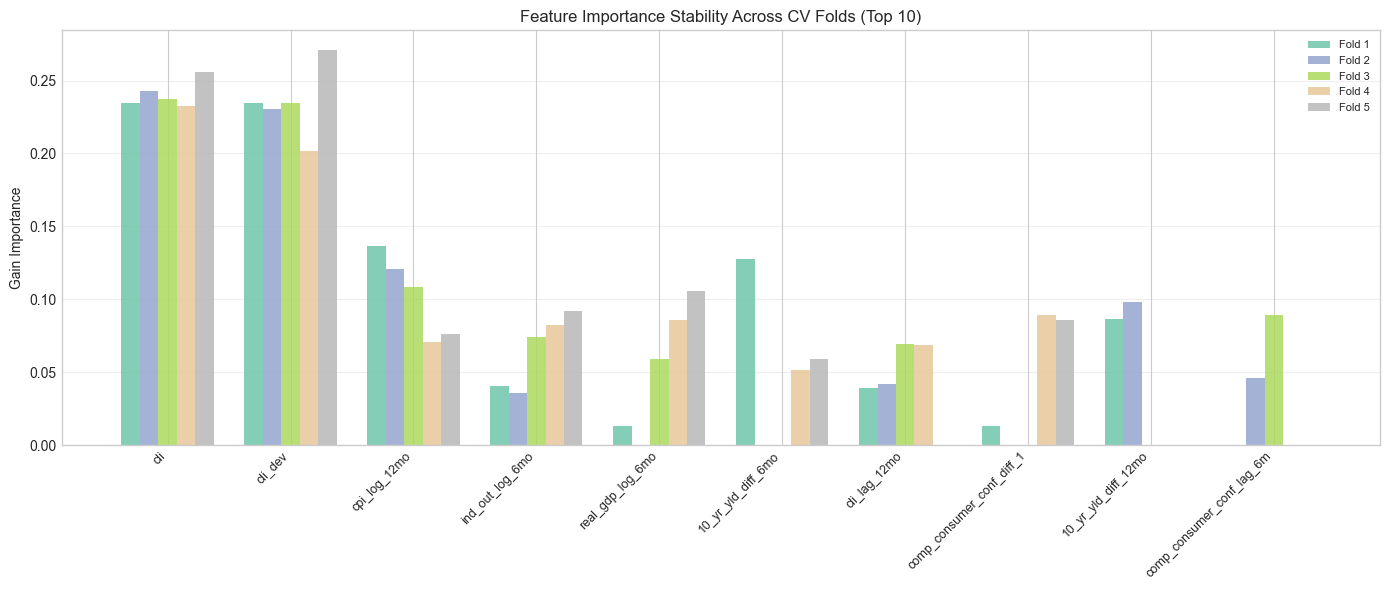

Importance Stability (Coefficient of Variation):
                     Feature   Mean    Std     CV
                         cli 0.2406 0.0085 0.0353
                     cli_dev 0.2344 0.0219 0.0936
                cpi_log_12mo 0.1025 0.0253 0.2472
             ind_out_log_6mo 0.0650 0.0226 0.3483
            real_gdp_log_6mo 0.0527 0.0408 0.7742
          10_yr_yld_diff_6mo 0.0476 0.0471 0.9903
                cli_lag_12mo 0.0437 0.0253 0.5797
comp_consumer_conf_diff_12mo 0.0377 0.0411 1.0899
         10_yr_yld_diff_12mo 0.0369 0.0454 1.2288
  comp_consumer_conf_lag_6mo 0.0270 0.0358 1.3245

Low CV = stable importance; High CV = importance varies with training period


In [9]:
top_10 = imp_df.head(10)['feature'].tolist()
top_10_idx = [selected_features.index(f) for f in top_10]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(top_10))
width = 0.15
colors = plt.cm.Set2(np.linspace(0, 1, N_SPLITS))

for fold in range(N_SPLITS):
    vals = [fold_importances[fold, i] for i in top_10_idx]
    ax.bar(x + fold * width, vals, width, label=f'Fold {fold+1}',
           color=colors[fold], alpha=0.8)

ax.set_xticks(x + width * (N_SPLITS - 1) / 2)
ax.set_xticklabels([f[:25] for f in top_10], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Gain Importance')
ax.set_title('Feature Importance Stability Across CV Folds (Top 10)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Coefficient of variation
cv_scores = []
for feat in top_10:
    idx = selected_features.index(feat)
    mean_val = fold_importances[:, idx].mean()
    std_val = fold_importances[:, idx].std()
    cv = std_val / mean_val if mean_val > 0 else float('inf')
    cv_scores.append({'Feature': feat, 'Mean': mean_val, 'Std': std_val, 'CV': cv})

cv_df = pd.DataFrame(cv_scores)
print('Importance Stability (Coefficient of Variation):')
print(cv_df.to_string(index=False, float_format='{:.4f}'.format))
print('\nLow CV = stable importance; High CV = importance varies with training period')

### Interpretation — Importance Stability

The stability analysis divides the top 10 features into two clear groups:

**Highly stable features (CV < 0.5):**
- **cli** (CV = 0.04) and **cli_dev** (CV = 0.09) are remarkably stable —
  their importance barely changes across folds. This means the CLI's predictive
  power is not tied to any specific economic era; it consistently provides the
  model's primary signal regardless of whether the training window includes the
  1980s recessions, the 1990s, or the 2000s financial crisis.
- **cpi_log_12mo** (CV = 0.25) and **ind_out_log_6mo** (CV = 0.35) are also
  reasonably stable, reinforcing their role as reliable recession indicators.

**Volatile features (CV > 0.5):**
- **real_gdp_log_6mo** (CV = 0.77) fluctuates considerably — it may be more
  important in periods with GDP-driven recessions (e.g., supply shocks) than in
  financially-driven downturns.
- **10_yr_yld_diff_6mo** (CV = 0.99) is near-random, suggesting that the
  predictive value of short-term yield changes is highly regime-dependent.
- **comp_consumer_conf_diff_12mo** (CV = 1.09) and
  **comp_consumer_conf_lag_6mo** (CV = 1.32) exceed 1.0, meaning their standard
  deviation is *larger than their mean*. These features may be capturing
  period-specific patterns rather than stable recession signals.

**Implications:** The stable core features (CLI, cli_dev, CPI, industrial
output) can be trusted as durable recession predictors. The volatile features
still add value in certain periods but should be weighted less heavily in any
model interpretation or policy application.

## 6. Leading vs. Coincident Indicator Analysis

Economic indicators are traditionally classified by their timing relative to the
business cycle:

- **Leading indicators** move *before* the economy turns — they are designed to
  signal recessions ahead of time. Examples: CLI, yield curve, stock prices, VIX,
  EPU, commodity prices.
- **Coincident indicators** move *with* the economy — they confirm a recession is
  happening but may not predict it in advance. Examples: unemployment, industrial
  output, CPI, GDP, retail sales, consumer confidence.
- **Lagged features** are engineered time-shifted versions (1/3/6/12-month lags)
  of other indicators. They allow the model to capture momentum and trend
  information.

For a **12-month-ahead** recession forecasting model, leading indicators should
ideally dominate — they are the features most likely to contain genuine
forward-looking signal. Heavy reliance on coincident indicators might suggest the
model is detecting recessions that are already underway rather than predicting
future ones.

Leading vs. Coincident Indicator Importance
      Type  Total Gain  N Features  Avg Gain
   Leading      0.5134          13    0.0395
Coincident      0.3054          10    0.0305
    Lagged      0.0966           6    0.0161
     Other      0.0845           5    0.0169
   Country      0.0000           3    0.0000


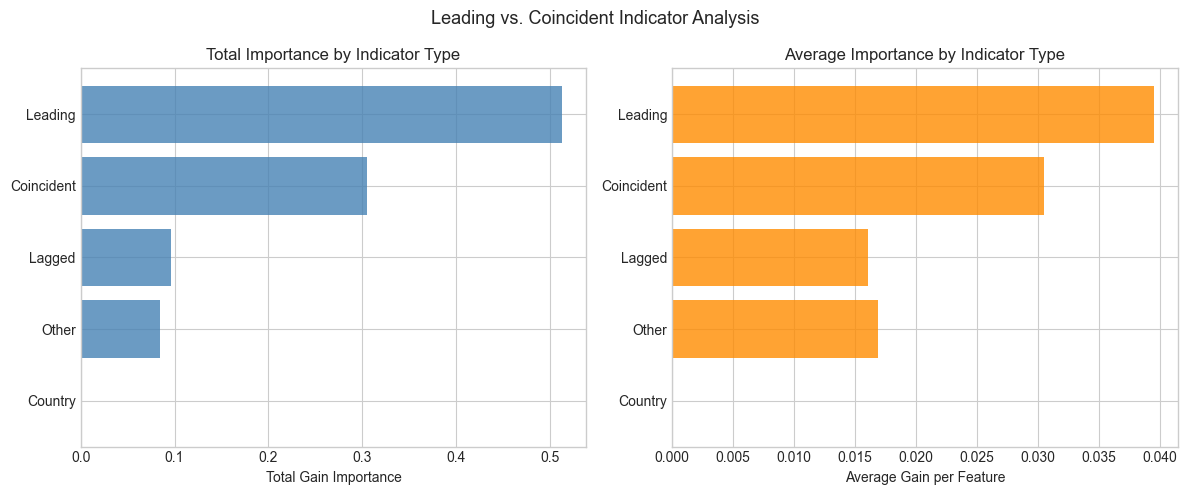

In [10]:
# Classify features as leading, coincident, or lagged versions
leading_kw = ['yield_spread', 'yield_curve', 'vix', 'epu', 'cli',
              'national_share_price', 'copper', 'oil', 'gps']
coincident_kw = ['unemployment', 'ind_out', 'cpi', 'retail', 'real_gdp',
                 'consumer_conf', 'comp_consumer_conf']
country_kw = ['country_']

feature_type = {}
for feat in selected_features:
    if '_lag_' in feat:
        feature_type[feat] = 'Lagged'
    elif any(x in feat for x in leading_kw):
        feature_type[feat] = 'Leading'
    elif any(x in feat for x in coincident_kw):
        feature_type[feat] = 'Coincident'
    elif any(feat.startswith(x) for x in country_kw):
        feature_type[feat] = 'Country'
    else:
        feature_type[feat] = 'Other'

type_imp = {}
type_count = {}
for feat, ftype in feature_type.items():
    idx = selected_features.index(feat)
    type_imp.setdefault(ftype, 0)
    type_imp[ftype] += mean_imp[idx]
    type_count.setdefault(ftype, 0)
    type_count[ftype] += 1

type_df = pd.DataFrame([
    {'Type': k, 'Total Gain': type_imp[k], 'N Features': type_count[k],
     'Avg Gain': type_imp[k] / type_count[k]}
    for k in type_imp
]).sort_values('Total Gain', ascending=False)

print('Leading vs. Coincident Indicator Importance')
print('=' * 60)
print(type_df.to_string(index=False, float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

type_plot = type_df.sort_values('Total Gain', ascending=True)
axes[0].barh(type_plot['Type'], type_plot['Total Gain'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Total Gain Importance')
axes[0].set_title('Total Importance by Indicator Type')

axes[1].barh(type_plot['Type'], type_plot['Avg Gain'], color='darkorange', alpha=0.8)
axes[1].set_xlabel('Average Gain per Feature')
axes[1].set_title('Average Importance by Indicator Type')

plt.suptitle('Leading vs. Coincident Indicator Analysis', fontsize=13)
plt.tight_layout()
plt.show()

### Interpretation — Leading vs. Coincident

The results confirm that the model appropriately relies on **leading indicators**
for its 12-month-ahead recession predictions:

- **Leading indicators** account for 0.51 total gain — more than all other
  categories combined. This is economically sound: the model is using
  forward-looking signals (CLI, yield curve movements, commodity prices) rather
  than merely detecting ongoing downturns.
- **Coincident indicators** contribute the second-largest total gain, reflecting
  the fact that features like industrial output growth and CPI changes can
  exhibit early warning patterns even though they are not traditionally
  classified as leading. The 6-month and 12-month log-changes effectively convert
  coincident indicators into momentum features that can anticipate turning
  points.
- **Lagged features** contribute moderate importance, indicating that the model
  benefits from seeing the trajectory of indicators over time — a declining CLI
  that was already low 12 months ago carries more weight than a sudden one-month
  dip.
- **Country dummies** contribute zero importance, confirming the model generalizes
  across nations without relying on country-specific intercepts.

The dominance of leading indicators validates the model's design — it is
genuinely *forecasting* recessions 12 months ahead rather than simply
*detecting* them contemporaneously.

## Summary

The table below consolidates the code output. Below it, we synthesize the key
takeaways from all six analyses.

In [11]:
print('Feature Importance Analysis Summary')
print('=' * 60)

print('\n1. Top 5 features by gain importance:')
for i, (_, row) in enumerate(imp_df.head(5).iterrows(), 1):
    print(f'   {i}. {row["feature"]}')

print('\n2. Top 5 features by permutation importance:')
for i, (_, row) in enumerate(perm_df.head(5).iterrows(), 1):
    print(f'   {i}. {row["feature"]}')

print('\n3. Top 5 features by mean |SHAP|:')
for i, (_, row) in enumerate(shap_rank.head(5).iterrows(), 1):
    print(f'   {i}. {row["feature"]}')

print(f'\n4. Most important category: {cat_df.iloc[0]["Category"]} '
      f'(total gain = {cat_df.iloc[0]["Total Gain"]:.4f})')

print(f'\n5. Dominant indicator type: {type_df.iloc[0]["Type"]} '
      f'(total gain = {type_df.iloc[0]["Total Gain"]:.4f})')

# Stability
stable = cv_df[cv_df['CV'] < 0.5]
volatile = cv_df[cv_df['CV'] >= 0.5]
print(f'\n6. Stable features (CV < 0.5): {len(stable)} / {len(cv_df)}')
if len(volatile) > 0:
    print(f'   Volatile features: {", ".join(volatile["Feature"].tolist())}')

Feature Importance Analysis Summary

1. Top 5 features by gain importance:
   1. cli
   2. cli_dev
   3. cpi_log_12mo
   4. ind_out_log_6mo
   5. real_gdp_log_6mo

2. Top 5 features by permutation importance:
   1. cli
   2. cli_dev
   3. real_gdp_log_6mo
   4. ind_out_log_6mo
   5. unemployment_12mo_min

3. Top 5 features by mean |SHAP|:
   1. cli
   2. ind_out_log_6mo
   3. real_gdp_log_6mo
   4. cli_dev
   5. cli_lag_12mo

4. Most important category: Leading Indicator (total gain = 0.5187)

5. Dominant indicator type: Leading (total gain = 0.5134)

6. Stable features (CV < 0.5): 4 / 10
   Volatile features: real_gdp_log_6mo, 10_yr_yld_diff_6mo, cli_lag_12mo, comp_consumer_conf_diff_12mo, 10_yr_yld_diff_12mo, comp_consumer_conf_lag_6mo


### Key Takeaways

**1. The OECD Composite Leading Indicator is the model's cornerstone.**
CLI and its derived features (cli_dev, cli_lag_12mo) rank at or near the top
across all three importance methods. CLI is also the most *stable* feature across
CV folds (CV = 0.04), meaning its predictive power is durable across different
economic eras. This aligns with the CLI's design purpose — it is a composite
index specifically constructed to signal turning points ahead of time.

**2. Three importance methods converge on the same top features.**
The agreement between gain importance, SHAP, and permutation importance for the
top 5 features (CLI, cli_dev, industrial output, real GDP, CPI) gives high
confidence that these are genuinely predictive rather than artifacts of any
single measurement approach. Where the methods diverge (e.g., CPI ranks higher
in gain than in SHAP), the discrepancies are explainable by known method biases.

**3. Leading indicators dominate, validating the 12-month forecasting horizon.**
Over half of all feature importance comes from leading indicators, confirming
the model is *forecasting* future recessions rather than detecting ongoing ones.
This is the most important validation of the model's design.

**4. Feature efficiency varies dramatically across economic domains.**
Leading indicators achieve 0.17 average gain per feature (3 features), while
financial markets achieve only 0.005 (12 features). Future iterations could
consider pruning the low-efficiency financial market features to reduce model
complexity without sacrificing performance.

**5. Six of the top 10 features are volatile across folds.**
Features like `10_yr_yld_diff_6mo` (CV = 0.99) and
`comp_consumer_conf_lag_6mo` (CV = 1.32) have importance that fluctuates
dramatically with the training period. Only four features (cli, cli_dev,
cpi_log_12mo, ind_out_log_6mo) maintain stable importance across all folds.
While the volatile features may add value in specific economic regimes, they
should not be over-interpreted in any single model run.

**6. Country identity does not drive predictions.**
Zero gain importance for all country dummies means the model has learned
generalizable recession patterns that apply across the 9 nations in our dataset,
rather than relying on country-specific shortcuts. This is a desirable property
for a multi-country forecasting model.